In [58]:
!pip install -q mlflow dagshub

In [59]:
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from PIL import Image

import mlflow
import mlflow.tensorflow
import dagshub

In [60]:
dagshub.init(
    repo_owner="Aryanupadhyay23",
    repo_name="Emotion-Detection-Deep-Learning",
    mlflow=True
)

mlflow.set_experiment("Emotion_Recognition_CustomCNN")

# Safe run start
if mlflow.active_run():
    mlflow.end_run()

mlflow.start_run(run_name="Custom_CNN_Mixup")

Initialized MLflow to track repo "Aryanupadhyay23/Emotion-Detection-Deep-Learning"

Repository Aryanupadhyay23/Emotion-Detection-Deep-Learning initialized!

<ActiveRun: >

In [61]:
DATASET_PATH = "/kaggle/input/datasets/sujaykapadnis/emotion-recognition-dataset/dataset"

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 50
SEED = 42

In [62]:
class_counts = {}
total_images = 0

for cls in os.listdir(DATASET_PATH):

    path = os.path.join(DATASET_PATH, cls)

    if os.path.isdir(path):

        count = len(os.listdir(path))
        class_counts[cls] = count
        total_images += count

print("Total Images:", total_images)
print("Class Distribution:", class_counts)

Total Images: 15453
Class Distribution: {'Surprise': 1234, 'Angry': 1313, 'Neutral': 4027, 'Sad': 3934, 'Happy': 3740, 'Ahegao': 1205}


In [63]:
mlflow.log_param("model","Custom CNN + MixUp")
mlflow.log_param("image_size",IMG_SIZE)
mlflow.log_param("batch_size",BATCH_SIZE)
mlflow.log_param("epochs",EPOCHS)

mlflow.log_param("optimizer","Adam")
mlflow.log_param("learning_rate",3e-4)

mlflow.log_param("dataset_size",total_images)
mlflow.log_param("num_classes",len(class_counts))

6

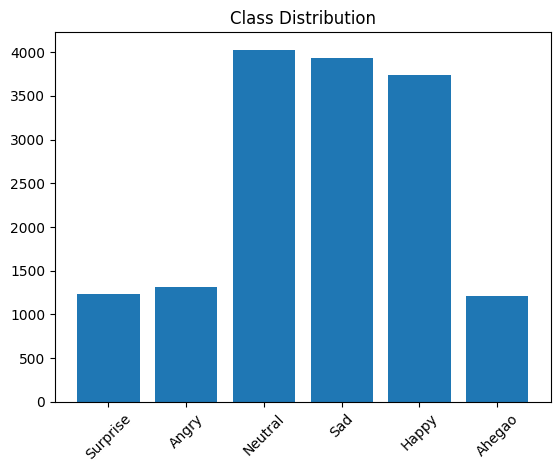

In [64]:
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")

plt.savefig("class_distribution.png")
mlflow.log_artifact("class_distribution.png")

plt.show()

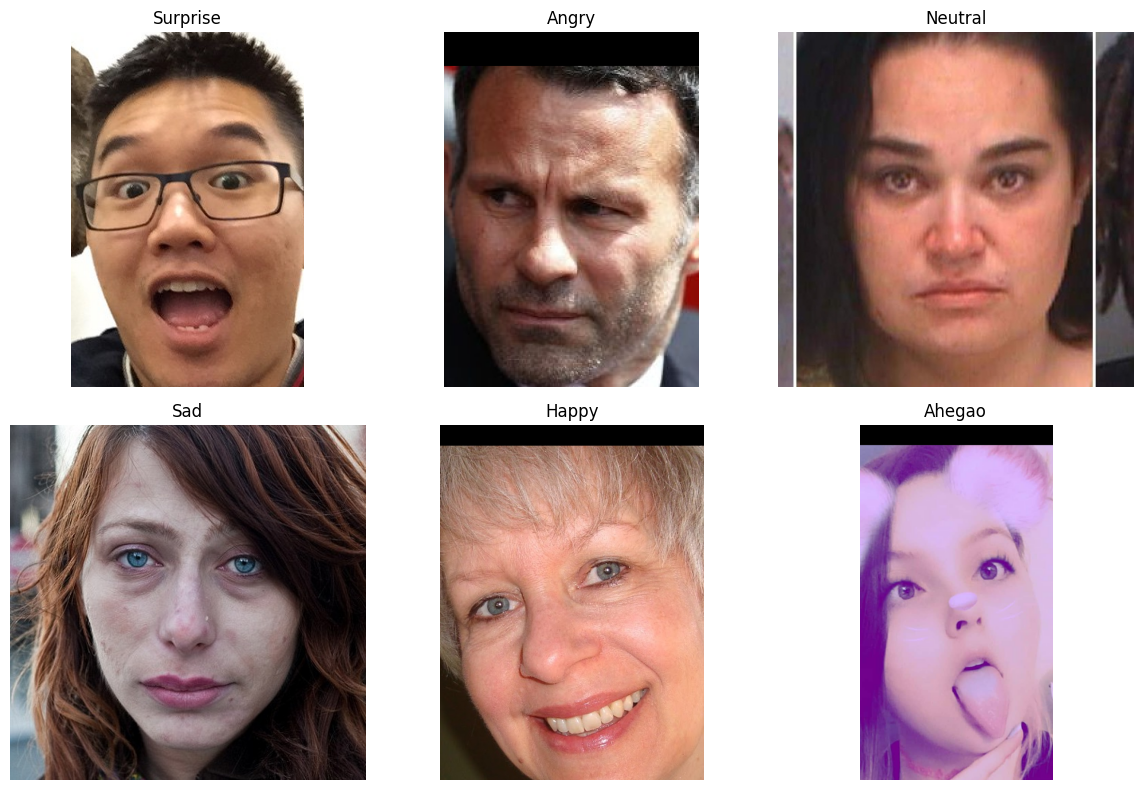

In [65]:
plt.figure(figsize=(12,8))

for i,cls in enumerate(class_counts.keys()):

    path=os.path.join(DATASET_PATH,cls)
    img=random.choice(os.listdir(path))

    img=Image.open(os.path.join(path,img))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()

plt.savefig("sample_images.png")
mlflow.log_artifact("sample_images.png")

plt.show()

In [66]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names=train_ds.class_names
num_classes=len(class_names)

Found 15453 files belonging to 6 classes.
Using 12363 files for training.
Found 15453 files belonging to 6 classes.
Using 3090 files for validation.


In [67]:
train_ds = train_ds.map(
    lambda x,y:(x,tf.one_hot(y,num_classes)),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda x,y:(x,tf.one_hot(y,num_classes)),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [68]:
labels=[]

for _,y in train_ds.unbatch():
    labels.append(np.argmax(y.numpy()))

labels=np.array(labels)

class_weights=compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights=dict(enumerate(class_weights))

print(class_weights)

mlflow.log_dict(class_weights,"class_weights.json")

{0: np.float64(2.1264189886480906), 1: np.float64(1.9347417840375587), 2: np.float64(0.6845514950166113), 3: np.float64(0.6415006226650062), 4: np.float64(0.65936), 5: np.float64(2.0982688391038695)}


In [69]:
def mixup(batch_images, batch_labels, alpha=0.2):

    batch_size=tf.shape(batch_images)[0]

    lambda_val=tf.random.uniform([],0,1)

    index=tf.random.shuffle(tf.range(batch_size))

    mixed_images=lambda_val*batch_images + (1-lambda_val)*tf.gather(batch_images,index)

    mixed_labels=lambda_val*batch_labels + (1-lambda_val)*tf.gather(batch_labels,index)

    return mixed_images, mixed_labels

In [70]:
train_ds = train_ds.map(
    lambda x,y: mixup(x,y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [71]:
AUTOTUNE=tf.data.AUTOTUNE

train_ds=train_ds.prefetch(AUTOTUNE)
val_ds=val_ds.prefetch(AUTOTUNE)

In [72]:
callbacks=[

    keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3
    )

]

In [73]:
inputs=keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))

x=layers.Rescaling(1./255)(inputs)

x=layers.Conv2D(32,3,padding="same")(x)
x=layers.BatchNormalization()(x)
x=layers.Activation("swish")(x)
x=layers.MaxPooling2D()(x)

x=layers.Conv2D(64,3,padding="same")(x)
x=layers.BatchNormalization()(x)
x=layers.Activation("swish")(x)
x=layers.MaxPooling2D()(x)

x=layers.SeparableConv2D(128,3,padding="same")(x)
x=layers.BatchNormalization()(x)
x=layers.Activation("swish")(x)
x=layers.MaxPooling2D()(x)

x=layers.SeparableConv2D(256,3,padding="same")(x)
x=layers.BatchNormalization()(x)
x=layers.Activation("swish")(x)
x=layers.GlobalAveragePooling2D()(x)

x=layers.Dense(256,activation="swish")(x)
x=layers.Dropout(0.5)(x)

outputs=layers.Dense(num_classes,activation="softmax")(x)

model=keras.Model(inputs,outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 32, 32, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 16, 16, 256)    │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 131,718 (514.52 KB)

 Trainable params: 130,758 (510.77 KB)

 Non-trainable params: 960 (3.75 KB)

In [74]:
loss_fn=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [75]:
mlflow.tensorflow.autolog(log_models=False)

history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.2667 - loss: 1.7163 - val_accuracy: 0.1877 - val_loss: 1.7285 - learning_rate: 3.0000e-04
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.3389 - loss: 1.6330 - val_accuracy: 0.3806 - val_loss: 1.5302 - learning_rate: 3.0000e-04
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.3589 - loss: 1.6046 - val_accuracy: 0.4113 - val_loss: 1.4860 - learning_rate: 3.0000e-04
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.3768 - loss: 1.5736 - val_accuracy: 0.4188 - val_loss: 1.4629 - learning_rate: 3.0000e-04
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.3884 - loss: 1.5649 - val_accuracy: 0.3799 - val_loss: 1.5136 - learning_rate: 3.0000e-04
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.4095 - loss: 1.5248 - val_accuracy: 0.4644 - val_loss: 1.3963 - learning_rate: 3.0000e-04
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/ste

2026/03/04 09:19:32 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


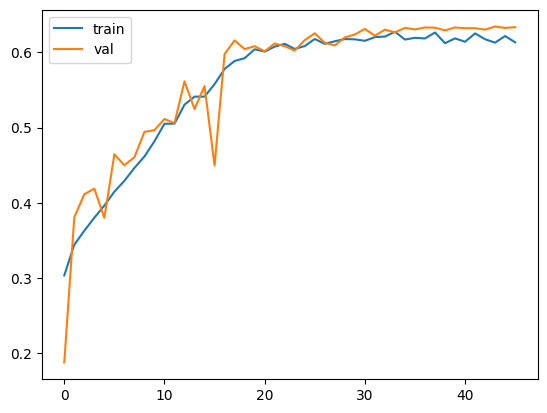

In [76]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["train","val"])

plt.savefig("training_curve.png")
mlflow.log_artifact("training_curve.png")

plt.show()

In [77]:
y_true=[]
y_pred=[]
y_prob=[]

for x,y in val_ds:

    preds=model.predict(x)

    y_true.extend(np.argmax(y.numpy(),axis=1))
    y_pred.extend(np.argmax(preds,axis=1))
    y_prob.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━

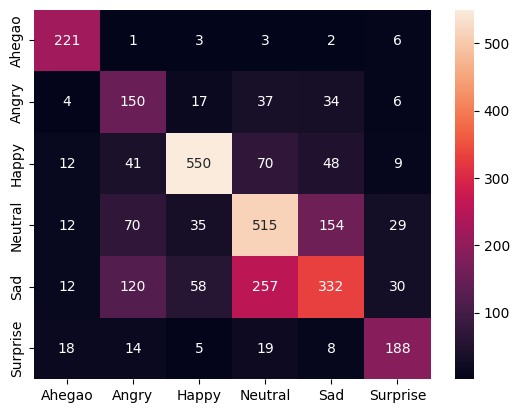

In [78]:
cm=confusion_matrix(y_true,y_pred)

sns.heatmap(cm,annot=True,fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.savefig("confusion_matrix.png")
mlflow.log_artifact("confusion_matrix.png")

plt.show()

In [79]:
report=classification_report(y_true,y_pred,target_names=class_names)

print(report)

with open("classification_report.txt","w") as f:
    f.write(report)

mlflow.log_artifact("classification_report.txt")

              precision    recall  f1-score   support

      Ahegao       0.79      0.94      0.86       236
       Angry       0.38      0.60      0.47       248
       Happy       0.82      0.75      0.79       730
     Neutral       0.57      0.63      0.60       815
         Sad       0.57      0.41      0.48       809
    Surprise       0.70      0.75      0.72       252

    accuracy                           0.63      3090
   macro avg       0.64      0.68      0.65      3090
weighted avg       0.64      0.63      0.63      3090



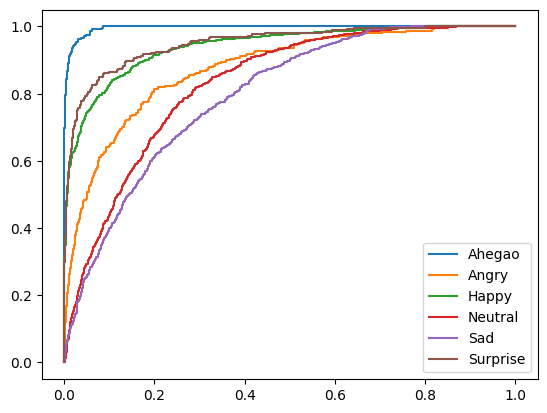

In [80]:
y_true_bin=label_binarize(y_true,classes=range(num_classes))
y_prob=np.array(y_prob)

for i in range(num_classes):

    fpr,tpr,_=roc_curve(y_true_bin[:,i],y_prob[:,i])

    plt.plot(fpr,tpr,label=class_names[i])

plt.legend()

plt.savefig("roc_curve.png")
mlflow.log_artifact("roc_curve.png")

plt.show()

In [81]:
sample=next(iter(val_ds))[0]

times=[]

for _ in range(5):

    start=time.time()
    model.predict(sample)
    end=time.time()

    times.append((end-start)/len(sample))

latency=np.mean(times)

mlflow.log_metric("latency_per_image",latency)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [82]:
best_model=tf.keras.models.load_model("best_model.keras")

mlflow.tensorflow.log_model(best_model,"emotion_model")

2026/03/04 09:19:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 09:19:47 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [83]:
best_model=tf.keras.models.load_model("best_model.keras")

mlflow.tensorflow.log_model(best_model,"emotion_model")

2026/03/04 09:20:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 09:20:07 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [84]:
mlflow.end_run()

🏃 View run Custom_CNN_Mixup at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/0/runs/4bedfc33359b463d97526f860fc85191
🧪 View experiment at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/0
